# **EDA Notebook**
IDX Exchange Weeks 2-3 Assignment 

by Jack Phelan : )

In [38]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from idx.utils import get_histogram, get_boxplot, get_missing_report, get_iqr_outliers
from idx.config import RAW_LISTINGS_DIR, RAW_SOLD_DIR
import numpy as np
import scipy.stats as stats
from pathlib import Path

In [39]:
# loading data from concat-ed csv
listings_df_raw = pd.read_csv(Path("..") / RAW_LISTINGS_DIR, low_memory=False)
sold_df_raw = pd.read_csv(Path("..") / RAW_SOLD_DIR, low_memory=False)

In [40]:
# previews
listings_df_raw.head(5)

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,4998888.0,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.0,NaN,90018,NaN,NaN,6192.0,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [41]:
sold_df_raw.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.0,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.0,...,95916,0.0,336283.2,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.0,554271746,crchapman@sbcglobal.net,2024-04-26,78000.0,...,95966,0.0,101495.0,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.0,543251400,michaelg@londonproperties.com,2024-04-02,250000.0,...,93726,0.0,8100.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.0,539236677,chris.campbell@msn.com,2024-04-10,815000.0,...,92223,0.0,564988.0,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.0,538449222,rrinder@sbcglobal.net,2024-04-06,15000.0,...,95966,0.0,6098.0,NaN,False,False,NaN,NaN,NaN,NaN


# **Listings Analysis**

## **Dataset Overview**

In [42]:
# basic info about data
print("Listings DataFrame Info:")
print(listings_df_raw.shape[0], "rows,", listings_df_raw.shape[1], "columns")
print("Number of float columns:", len(listings_df_raw.select_dtypes(include=['float64']).columns.tolist()))
print("Number of int columns:", len(listings_df_raw.select_dtypes(include=['int64']).columns.tolist()))
print("Number of object columns:", len(listings_df_raw.select_dtypes(include=['object']).columns.tolist()))
print("Number of string columns:", len(listings_df_raw.select_dtypes(include=['string']).columns.tolist()))

Listings DataFrame Info:
893594 rows, 84 columns
Number of float columns: 32
Number of int columns: 4
Number of object columns: 48
Number of string columns: 0


In [43]:
# specific dtypes 
display(listings_df_raw.dtypes) #low_memory=False on read changes str columns to objects

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 84, dtype: object

In [44]:
listings_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893594 entries, 0 to 893593
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             890150 non-null  float64
 1   ListingKey                    893594 non-null  int64  
 2   ListAgentEmail                891222 non-null  object 
 3   CloseDate                     257985 non-null  object 
 4   ClosePrice                    233372 non-null  float64
 5   ListAgentFirstName            888314 non-null  object 
 6   ListAgentLastName             893511 non-null  object 
 7   Latitude                      781122 non-null  float64
 8   Longitude                     781848 non-null  float64
 9   UnparsedAddress               891239 non-null  object 
 10  PropertyType                  893594 non-null  object 
 11  LivingArea                    782759 non-null  float64
 12  ListPrice                     891376 non-nul

Notes on datatypes 
- date cols are not actually datetime (but mostly empty anyway so not super important / just ask about it at meeting)
- 

## **Missingness Assessment**

In [45]:
listings_missing_report = get_missing_report(listings_df_raw, flag_high_missing=True, threshold=0.9, index_col='column')

display(listings_missing_report)

,missing_count,pct_missing,high_missing
column,,,
FireplacesTotal,893594,100.0,True
ElementarySchoolDistrict,893594,100.0,True
MiddleOrJuniorSchoolDistrict,893594,100.0,True
CoveredSpaces,893594,100.0,True
AboveGradeFinishedArea,893594,100.0,True
...,...,...,...
MlsStatus,0,0.0,False
ListingKey,0,0.0,False
ListingId,0,0.0,False


In [ ]:
# COLUMN GROUP DECLARATIONS
METADATA_COLS = [
    "ListingKey",
    "BuyerAgentMlsId",
    "ListingKeyNumeric",
    "MlsStatus",
    "ListingId",
]


# COLUMNS THAT SHOULD PROBABLY BE DROPPED
COLS_TO_DROP = listings_missing_report[
    listings_missing_report["high_missing"]
].index.tolist()  # 90% Missing or more

AGENT_COLS = [
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentMlsId",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "ListAgentFirstName.1",
    "BuyerOfficeAOR",
    "CoBuyerAgentFirstName",
    "ListAgentLastName.1",
    "BuyerOfficeName.1",
    "BuyerAgencyCompensationType",
    "BuyerAgencyCompensation",
]

REGIONAL_COLS = [
    "Latitude",
    "Longitude",
    "UnparsedAddress",
    "AboveGradeFinishedArea",
    "MLSAreaMajor",
    "CountyOrParish",
    "ElementarySchool",
    "SubdivisionName",
    "StreetNumberNumeric",
    "City",
    "Longitude.1",
    "ElementarySchoolDistrict",
    "BelowGradeFinishedArea",
    "Latitude.1",
    "StateOrProvince",
    "MiddleOrJuniorSchool",
    "HighSchool",
    "HighSchoolDistrict",
    "PostalCode",
    "MiddleOrJuniorSchoolDistrict",
    "UnparsedAddress.1",
]


# FOR LATER USAGE
NUMERIC_FIELDS_TO_ANALYZE = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt",
]

CONTINUOUS_COLS = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
]

DISCRETE_COLS = ["BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "DaysOnMarket"]

# CHECK DISTRIBUTION OF THESE GUYS
DISTR_COLS = ["ClosePrice", "LivingArea", "DaysOnMarket"]

## **Numeric Distribution Analysis**

Analyze the distribution of key numeric fields: 
- ClosePrice, 
- ListPrice, 
- OriginalListPrice, 
- LivingArea,
- LotSizeAcres, 
- BedroomsTotal, 
- BathroomsTotalInteger, 
- DaysOnMarket, 
- YearBuilt. 




For each field:
-  generate histograms,
-  boxplots,
-  percentile summaries,
-  identify extreme outliers for later handling.

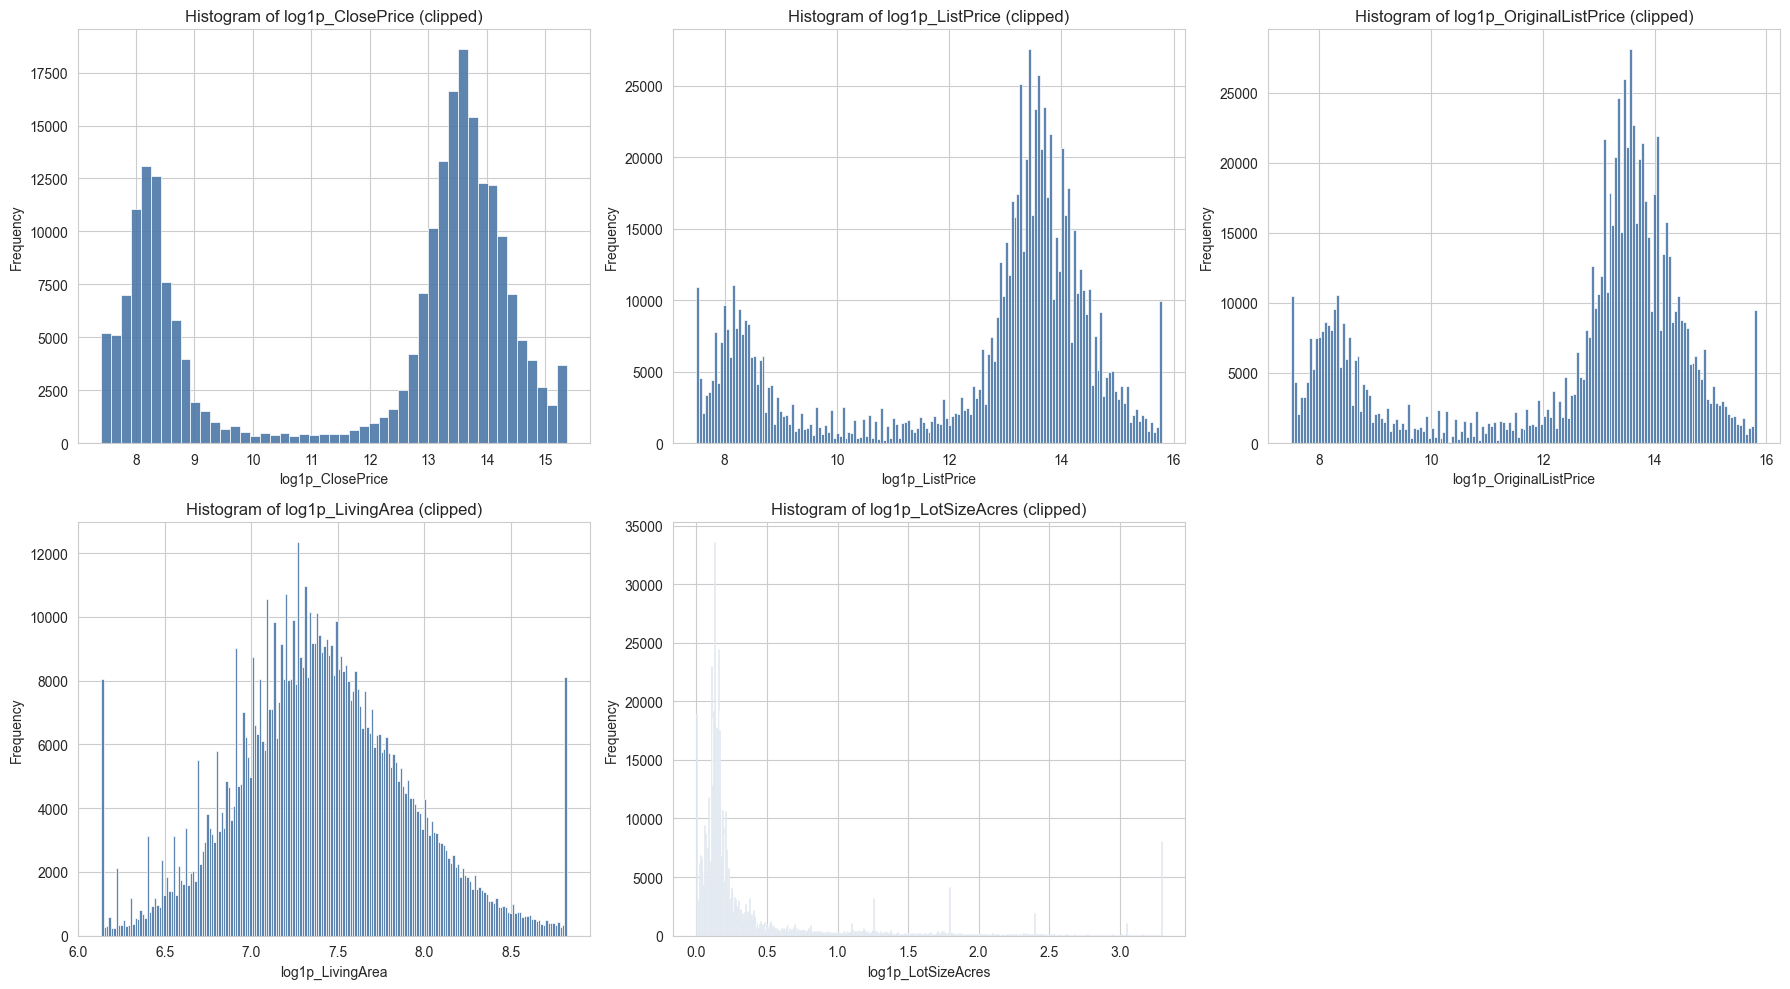

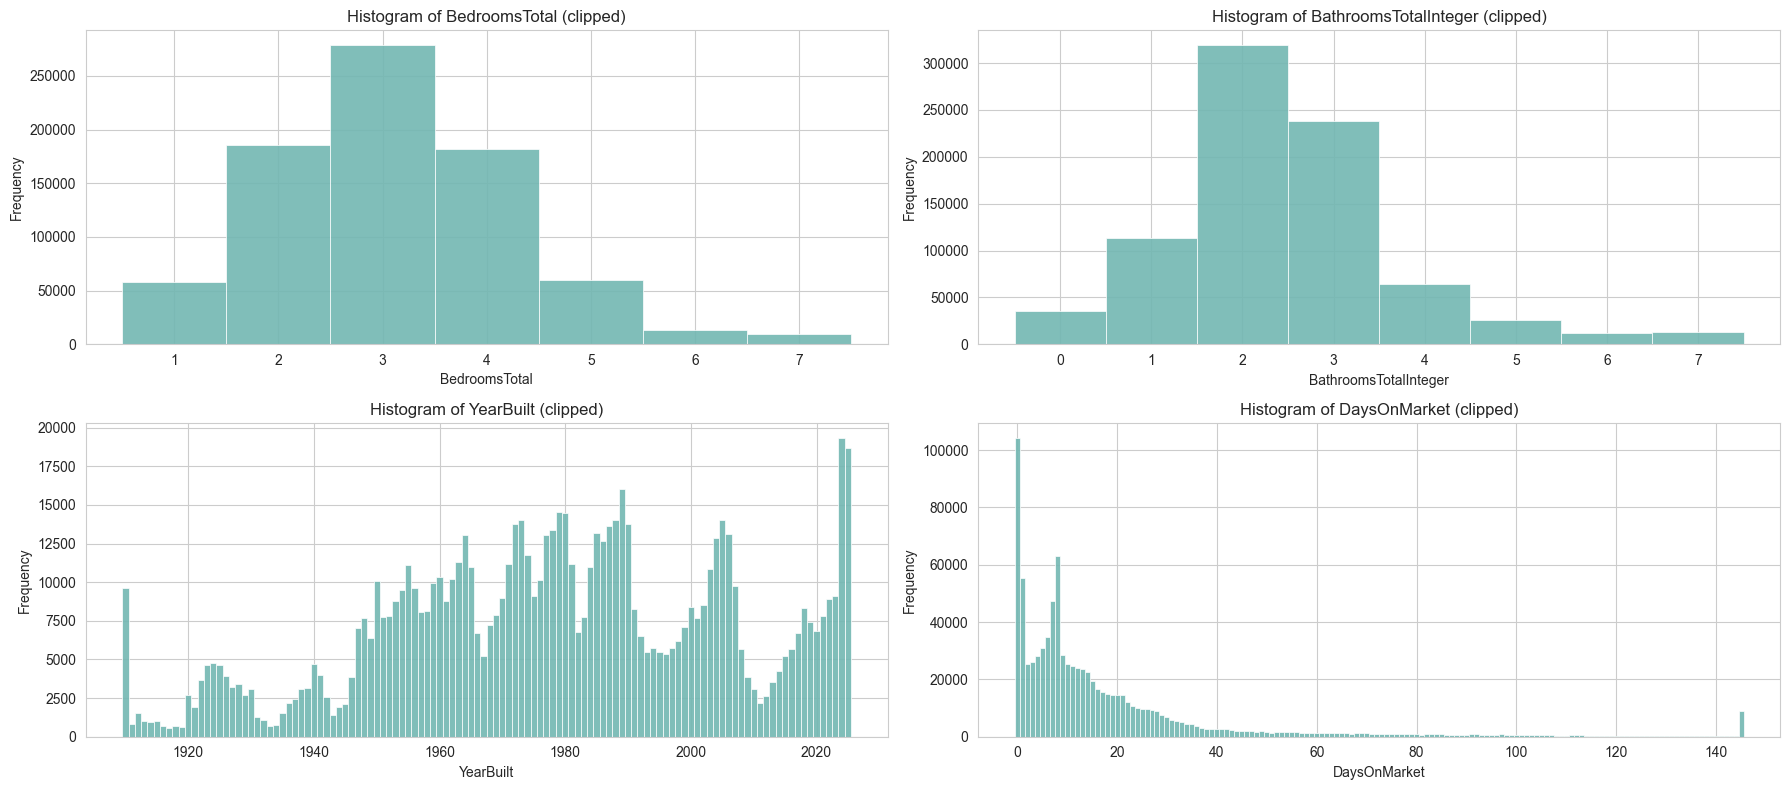

In [47]:
plot_df = listings_df_raw.copy()
plot_df["DaysOnMarket"] = pd.to_numeric(plot_df["DaysOnMarket"], errors="coerce").clip(lower=0)

# Use log1p on heavy-tailed continuous features for better shape visibility.
log_cols = []
for column in CONTINUOUS_COLS:
    log_col = f"log1p_{column}"
    values = pd.to_numeric(plot_df[column], errors="coerce").clip(lower=0)
    plot_df[log_col] = np.log1p(values)
    log_cols.append(log_col)

get_histogram(
    plot_df,
    col=log_cols,
    bins='auto',
    clip_lower=plot_df[log_cols].quantile(0.01),
    clip_upper=plot_df[log_cols].quantile(0.99),
    ncols=3,
    figsize=(18, 10),
    edgecolor="white",
    linewidth=0.5,
    color="#4C78A8",
    alpha=0.9,
    
)

get_histogram(
    plot_df,
    col=DISCRETE_COLS,
    bins='auto',
    clip_lower=plot_df[DISCRETE_COLS].quantile(0.01),
    clip_upper=plot_df[DISCRETE_COLS].quantile(0.99), #clipping needed because the scale goes insane otherwise aka lots of outliers > : (
    ncols=2,
    figsize=(18, 8),
    edgecolor="white",
    linewidth=0.5,
    color="#72B7B2",
    alpha=0.9,
    discrete=True
)


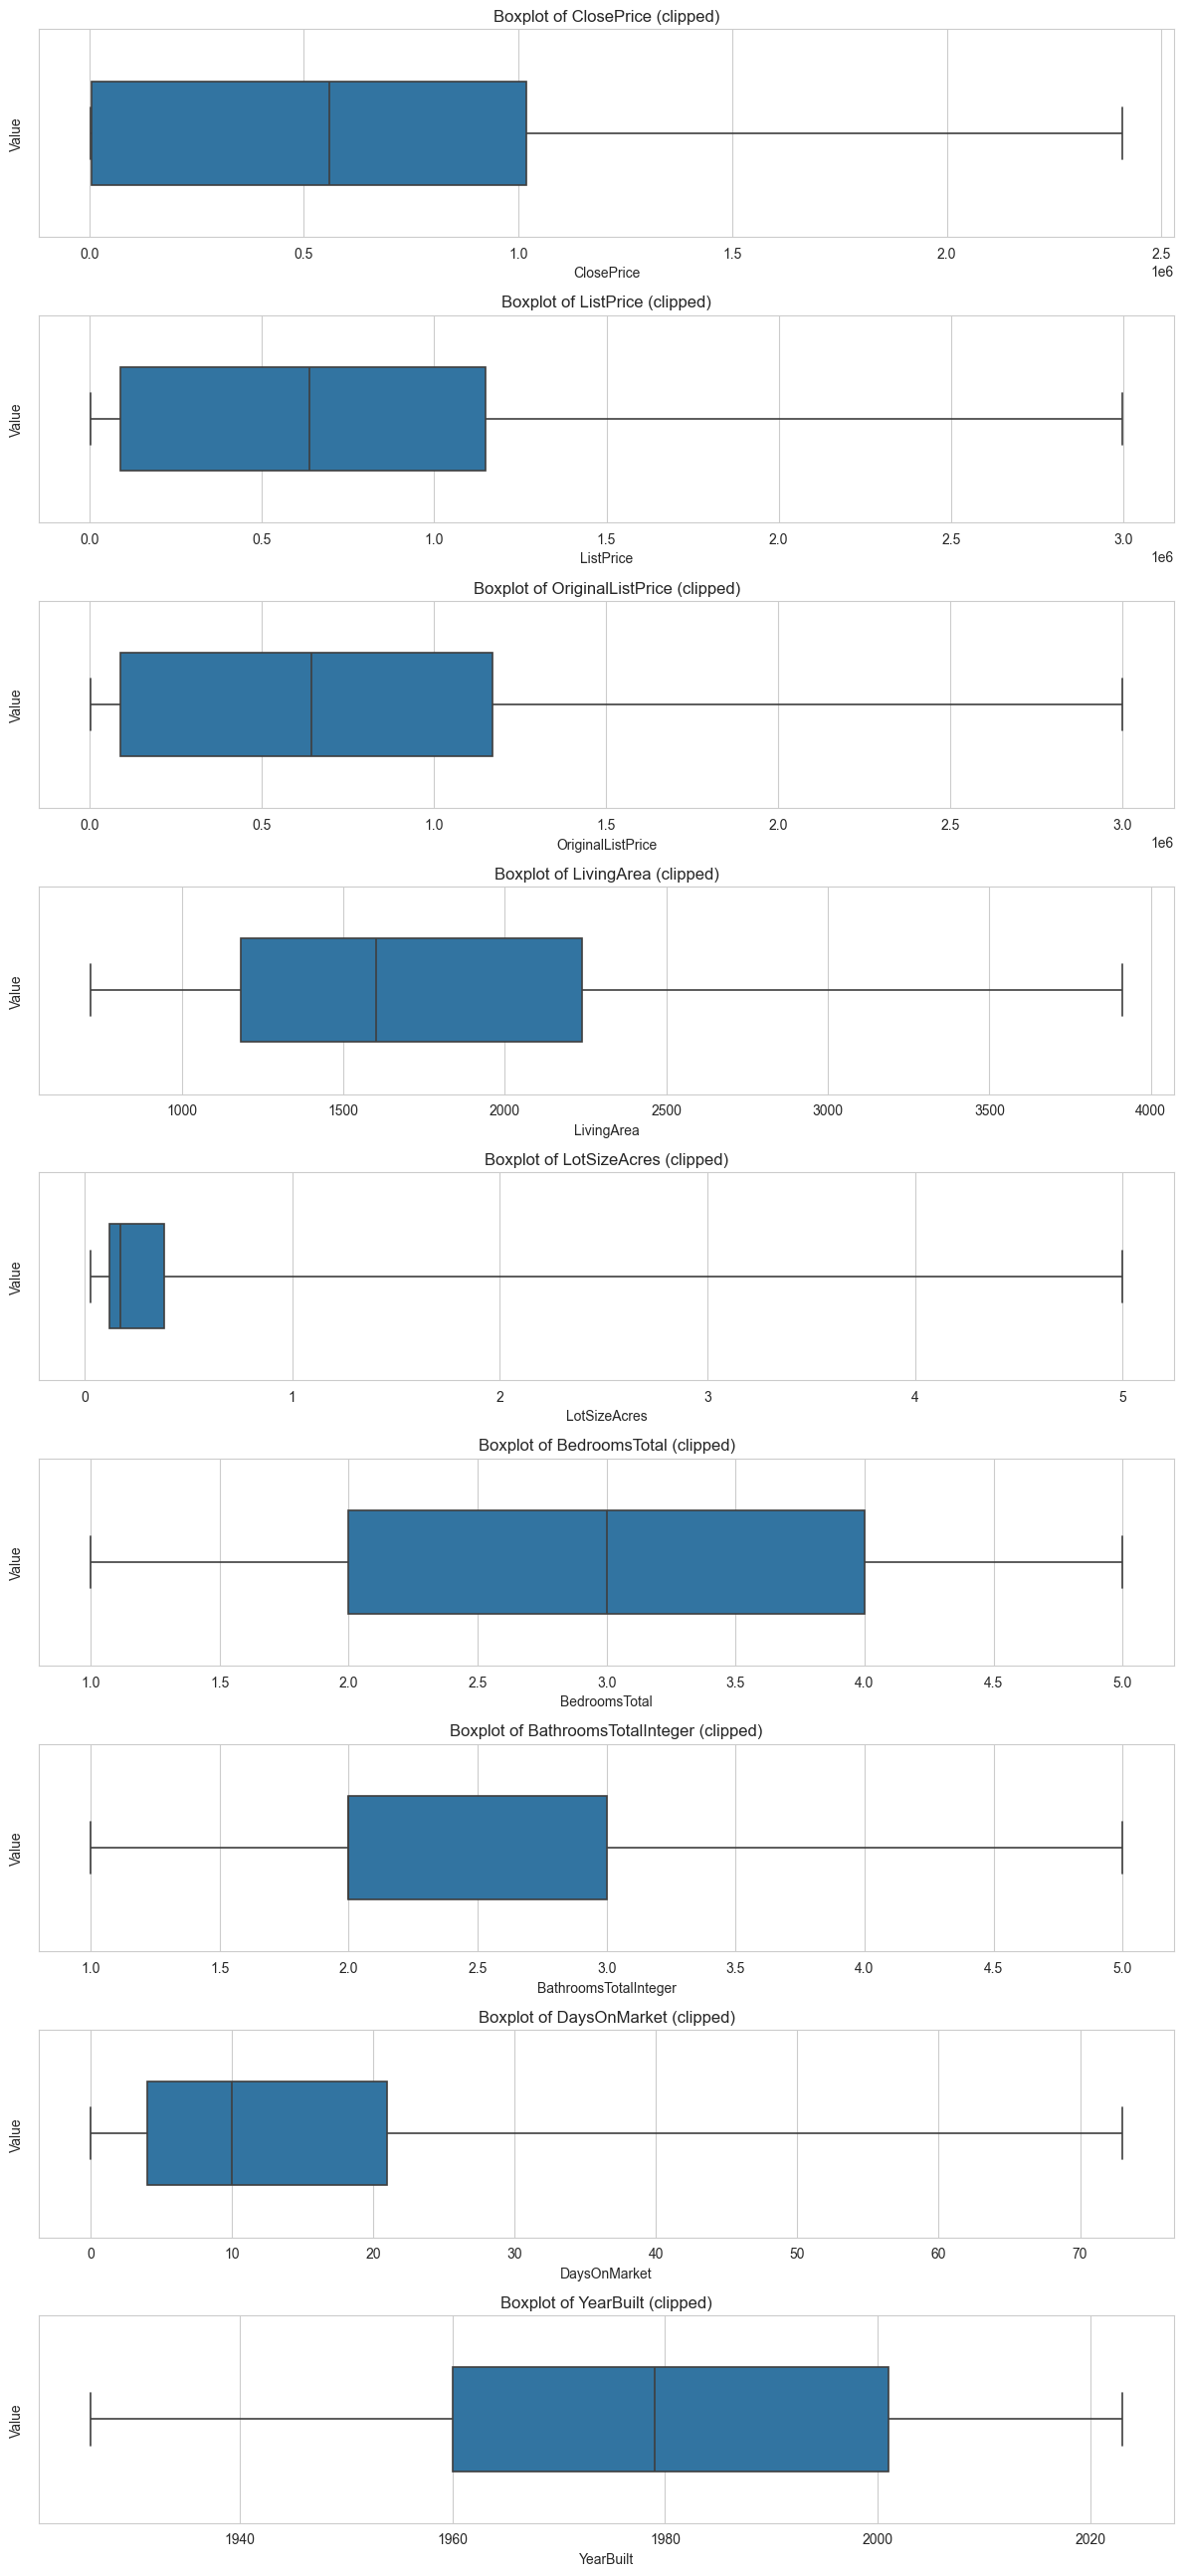

In [48]:
get_boxplot(
    listings_df_raw,
    col=NUMERIC_FIELDS_TO_ANALYZE,
    clip_lower=listings_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.01),
    clip_upper=listings_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.99),
    ncols=1,
    figsize=(12, 26),
    showfliers=False,
    whis=(5, 95),
    linewidth=1.2,
    width=0.5,
)

In [49]:
listings_df_raw[DISTR_COLS].describe()

,ClosePrice,LivingArea,DaysOnMarket
count,2.333720e+05,7.827590e+05,893594.000000
mean,7.789454e+05,3.104491e+03,18.571821
std,3.457924e+06,1.027712e+06,28.357769
min,0.000000e+00,0.000000e+00,-58.000000
25%,4.995000e+03,1.183000e+03,4.000000
50%,5.600000e+05,1.603000e+03,10.000000
75%,1.020000e+06,2.239000e+03,21.000000
max,8.200000e+08,9.090909e+08,2539.000000


## **Outlier Detection**

In [50]:
numeric_outliers = get_iqr_outliers(listings_df_raw, NUMERIC_FIELDS_TO_ANALYZE, threshold=3.0) # 3.0 for EXTREME outliers

Outlier Counts (Threshold: 3.0 * IQR)
----------------------------------------
ClosePrice: 3451 outliers (0.39% of total records)
ListPrice: 22703 outliers (2.54% of total records)
OriginalListPrice: 22752 outliers (2.55% of total records)
LivingArea: 14651 outliers (1.64% of total records)
LotSizeAcres: 108046 outliers (12.09% of total records)
BedroomsTotal: 2491 outliers (0.28% of total records)
BathroomsTotalInteger: 12589 outliers (1.41% of total records)
DaysOnMarket: 45113 outliers (5.05% of total records)
YearBuilt: 39 outliers (0.00% of total records)


DaysOnMarket has 10,4266 zeroes, as well as 36 negatives. Will have to ask about data specifically

In [51]:
"""from data_profiling import ProfileReport
from IPython.display import display
    
profile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)

profile.to_file("listings_profile_report.html")
"""

'from data_profiling import ProfileReport\nfrom IPython.display import display\n\nprofile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)\n\nprofile.to_file("listings_profile_report.html")\n'